# Decision Tree Theory and Pruning

## Purpose of This Notebook

This notebook covers the missing Decision Tree theory from the uploaded classification materials.

The previous Decision Tree notebook focused mainly on practical modelling.

This notebook focuses on understanding the theory behind Decision Trees.

## What This Notebook Covers

1. Decision Tree structure
2. Root node, internal node, branch, and leaf node
3. IF-THEN rule interpretation
4. How a tree chooses a split
5. Gini Index
6. Entropy
7. Information Gain
8. Information Gain bias
9. Gain Ratio
10. Hypothesis space
11. Greedy search and no backtracking
12. Inductive bias
13. Occam’s Razor
14. Decision regions and boundaries
15. Overfitting in Decision Trees
16. Pre-pruning
17. Post-pruning
18. Subtree replacement and subtree raising
19. Error-based pruning
20. Complexity-based pruning
21. MDL idea

## 1. Decision Tree Structure

A Decision Tree is a model that makes predictions by asking a sequence of questions.

Each question splits the data into smaller groups.

The model continues asking questions until it reaches a final answer.

In classification, the final answer is a class label.

In our customer segmentation case, the final answer could be:

- Segment `A`
- Segment `B`
- Segment `C`
- Segment `D`

## Main Parts of a Decision Tree

| Tree Part | Meaning |
|---|---|
| Root Node | The first question asked by the tree |
| Internal Node | A question asked after the root node |
| Branch | The path followed after answering a question |
| Leaf Node | The final prediction |

## Simple Example

A Decision Tree may ask:

1. Is the customer young?
2. Is the spending score low?
3. Is the customer a healthcare worker?

Based on the answers, it predicts a customer segment.

## Business Meaning

A Decision Tree is useful because it works like a simple rule system.

It can be explained as:

> If this condition is true, go left.  
> If not, go right.  
> Continue until a final segment is predicted.

In [1]:
# Code Cell 1A: Simple Decision Tree Rule Example

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a small customer example
# ------------------------------------------------------------
# This small table is only for understanding how a tree thinks.
#
# Each row = one customer
# The tree will use simple customer information to decide a segment.

customer_examples = pd.DataFrame({
    "customer": [
        "Customer 1",
        "Customer 2",
        "Customer 3",
        "Customer 4"
    ],
    "age_group": [
        "Young",
        "Young",
        "Older",
        "Older"
    ],
    "spending_score": [
        "Low",
        "High",
        "Low",
        "High"
    ],
    "segment": [
        "D",
        "B",
        "A",
        "C"
    ]
})

# ------------------------------------------------------------
# Step 2: Display the simple example
# ------------------------------------------------------------

display(customer_examples)

,customer,age_group,spending_score,segment
0,Customer 1,Young,Low,D
1,Customer 2,Young,High,B
2,Customer 3,Older,Low,A
3,Customer 4,Older,High,C


### Simple Decision Tree Rule Interpretation

The small example shows how a Decision Tree can make predictions using simple rules.

| Customer Pattern | Predicted Segment |
|---|---|
| Young + Low Spending | D |
| Young + High Spending | B |
| Older + Low Spending | A |
| Older + High Spending | C |

A Decision Tree does not compare customers by distance like KNN.

Instead, it asks questions step by step.

For example:

1. Is the customer young or older?
2. Is the spending score low or high?
3. Based on the answers, choose the final segment.

This is why Decision Trees are easy to explain as business rules.

## 1.1 Decision Path

A Decision Tree makes a prediction by following a path.

The path starts at the first question and ends at a final segment.

For example, if we want to predict the segment for a young customer with low spending, the tree may follow this logic:

1. Check the customer age group.
2. Check the spending score.
3. Predict the final customer segment.

This path is useful because it explains why the model made a prediction.

In [2]:
# Code Cell 1B: Decision Path Example

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a simple decision path
# ------------------------------------------------------------
# This table shows how one customer moves through tree questions.
#
# Example customer:
# - age_group = Young
# - spending_score = Low
#
# The tree uses these answers to reach the final segment.

decision_path = pd.DataFrame({
    "step": [
        1,
        2,
        3
    ],
    "tree_question": [
        "Is the customer Young?",
        "Is the Spending Score Low?",
        "Final prediction"
    ],
    "customer_answer": [
        "Yes",
        "Yes",
        "Segment D"
    ],
    "meaning": [
        "The customer goes to the Young branch",
        "The customer goes to the Low Spending branch",
        "The tree predicts this customer as Segment D"
    ]
})

# ------------------------------------------------------------
# Step 2: Display the decision path
# ------------------------------------------------------------

display(decision_path)

,step,tree_question,customer_answer,meaning
0,1,Is the customer Young?,Yes,The customer goes to the Young branch
1,2,Is the Spending Score Low?,Yes,The customer goes to the Low Spending branch
2,3,Final prediction,Segment D,The tree predicts this customer as Segment D


### Decision Path Interpretation

The decision path shows how one customer reaches a final prediction.

For this example:

| Step | Meaning |
|---|---|
| Step 1 | The tree checks whether the customer is young |
| Step 2 | The tree checks whether the spending score is low |
| Step 3 | The tree predicts Segment `D` |

This is the main strength of a Decision Tree.

It does not only give a prediction.  
It also gives a readable path that explains how the prediction was made.

This is why Decision Trees are often useful in business problems where explanation is important.

## 2. Gini Index

A Decision Tree needs to decide which question to ask first.

For example, the tree may ask:

- Should I split customers by age group?
- Should I split customers by spending score?
- Should I split customers by profession?

To make this decision, the tree needs a way to measure how good a split is.

One common measure is called the **Gini Index**.

## What Gini Index Means

Gini Index measures how mixed a group is.

If a group contains customers from many different segments, the group is mixed.

If a group contains customers from only one segment, the group is clean.

| Gini Value | Meaning |
|---:|---|
| 0.00 | Perfectly clean group |
| Higher value | More mixed group |

A Decision Tree prefers splits that create cleaner groups.

In simple words:

**Lower Gini is better.**

## Business Meaning

If a split creates groups where each group mostly belongs to one customer segment, that split is useful.

If a split creates groups where many customer segments are still mixed together, that split is less useful.

In [3]:
# Code Cell 2A: Calculate Gini for a Simple Group

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a simple function to calculate Gini
# ------------------------------------------------------------
# segment_values = the segment labels inside one group
#
# Example:
# ["A", "A", "A"] is a clean group
# ["A", "B", "C"] is a mixed group

def calculate_gini(segment_values):
    # Count how often each segment appears in the group
    segment_counts = pd.Series(segment_values).value_counts()
    
    # Convert counts into percentages
    segment_percentages = segment_counts / len(segment_values)
    
    # Gini formula:
    # 1 - sum of squared percentages
    gini_value = 1 - sum(segment_percentages ** 2)
    
    return round(gini_value, 3)


# ------------------------------------------------------------
# Step 2: Create two simple groups
# ------------------------------------------------------------
# clean_group = all customers belong to the same segment
# mixed_group = customers belong to different segments

clean_group = ["A", "A", "A", "A"]

mixed_group = ["A", "B", "C", "D"]


# ------------------------------------------------------------
# Step 3: Calculate Gini for both groups
# ------------------------------------------------------------

clean_group_gini = calculate_gini(clean_group)
mixed_group_gini = calculate_gini(mixed_group)


# ------------------------------------------------------------
# Step 4: Show the result in a clean table
# ------------------------------------------------------------

gini_example_table = pd.DataFrame({
    "group_name": [
        "Clean group",
        "Mixed group"
    ],
    "segment_values": [
        clean_group,
        mixed_group
    ],
    "gini_value": [
        clean_group_gini,
        mixed_group_gini
    ],
    "interpretation": [
        "All customers are from one segment",
        "Customers are spread across different segments"
    ]
})

display(gini_example_table)

,group_name,segment_values,gini_value,interpretation
0,Clean group,"[A, A, A, A]",0.00,All customers are from one segment
1,Mixed group,"[A, B, C, D]",0.75,Customers are spread across different segments


## 2.1 Comparing Two Possible Splits

A Decision Tree chooses a split by comparing possible questions.

For example, the tree may compare:

1. Split customers by `age_group`
2. Split customers by `spending_score`

The tree checks which split creates cleaner groups.

A clean group means most customers inside that group belong to the same segment.

To compare splits, we calculate the Gini value after each split.

The better split is usually the one with the lower weighted Gini value.

In simple words:

**Lower weighted Gini means a better split.**

In [4]:
# Code Cell 2B: Compare Two Splits Using Gini

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a small example dataset
# ------------------------------------------------------------
# This data is small on purpose.
# It helps us clearly see how a Decision Tree compares splits.
#
# segment = correct customer segment

split_example_data = pd.DataFrame({
    "customer": [
        "Customer 1", "Customer 2", "Customer 3", "Customer 4",
        "Customer 5", "Customer 6", "Customer 7", "Customer 8"
    ],
    "age_group": [
        "Young", "Young", "Young", "Young",
        "Older", "Older", "Older", "Older"
    ],
    "spending_score": [
        "Low", "Low", "High", "High",
        "Low", "Low", "High", "High"
    ],
    "segment": [
        "D", "D", "B", "B",
        "A", "C", "A", "C"
    ]
})

display(split_example_data)


# ------------------------------------------------------------
# Step 2: Create a function for weighted Gini
# ------------------------------------------------------------
# split_column = the column we want to split by
#
# Example:
# If split_column = "age_group",
# the data is split into Young and Older groups.
#
# Weighted Gini combines the Gini values of all groups after the split.

def calculate_weighted_gini(data, split_column, target_column):
    total_rows = len(data)
    weighted_gini = 0
    
    # Go through each group created by the split column
    for group_name, group_data in data.groupby(split_column):
        group_size = len(group_data)
        group_weight = group_size / total_rows
        
        group_gini = calculate_gini(group_data[target_column])
        
        weighted_gini += group_weight * group_gini
    
    return round(weighted_gini, 3)


# ------------------------------------------------------------
# Step 3: Compare two possible splits
# ------------------------------------------------------------

age_split_gini = calculate_weighted_gini(
    data=split_example_data,
    split_column="age_group",
    target_column="segment"
)

spending_split_gini = calculate_weighted_gini(
    data=split_example_data,
    split_column="spending_score",
    target_column="segment"
)


# ------------------------------------------------------------
# Step 4: Create a result table
# ------------------------------------------------------------

split_comparison = pd.DataFrame({
    "possible_split": [
        "Split by age_group",
        "Split by spending_score"
    ],
    "weighted_gini": [
        age_split_gini,
        spending_split_gini
    ]
})

# Add a simple decision column
split_comparison["split_quality"] = split_comparison["weighted_gini"].apply(
    lambda value: "Better split" if value == split_comparison["weighted_gini"].min() else "Weaker split"
)

display(split_comparison)

,customer,age_group,spending_score,segment
0,Customer 1,Young,Low,D
1,Customer 2,Young,Low,D
2,Customer 3,Young,High,B
3,Customer 4,Young,High,B
4,Customer 5,Older,Low,A
5,Customer 6,Older,Low,C
6,Customer 7,Older,High,A
7,Customer 8,Older,High,C


,possible_split,weighted_gini,split_quality
0,Split by age_group,0.500,Better split
1,Split by spending_score,0.625,Weaker split


## 3. Entropy

Entropy is another measure used by Decision Trees.

Like Gini, entropy checks how mixed a group is.

A group is clean when most customers inside it belong to the same segment.

A group is mixed when customers from many different segments are inside the same group.

## Simple Meaning

| Entropy Value | Meaning |
|---:|---|
| 0.00 | Perfectly clean group |
| Higher value | More mixed group |

In simple words:

**Lower entropy means less confusion.**

## Business Meaning

If a group contains only one customer segment, the model can predict that segment confidently.

If a group contains many different customer segments, the model is less sure.

Entropy helps the Decision Tree find splits that reduce confusion.

In [5]:
# Code Cell 3A: Calculate Entropy for Simple Groups

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Step 1: Create a simple function to calculate entropy
# ------------------------------------------------------------
# segment_values = the segment labels inside one group
#
# Example:
# ["A", "A", "A"] is a clean group
# ["A", "B", "C"] is a mixed group

def calculate_entropy(segment_values):
    # Count how often each segment appears in the group
    segment_counts = pd.Series(segment_values).value_counts()
    
    # Convert counts into percentages
    segment_percentages = segment_counts / len(segment_values)
    
    # Entropy formula:
    # - sum of percentage * log2(percentage)
    entropy_value = -sum(
        segment_percentages * np.log2(segment_percentages)
    )
    
    return round(entropy_value, 3)


# ------------------------------------------------------------
# Step 2: Create two simple groups
# ------------------------------------------------------------
# clean_group = all customers belong to the same segment
# mixed_group = customers belong to different segments

clean_group = ["A", "A", "A", "A"]

mixed_group = ["A", "B", "C", "D"]


# ------------------------------------------------------------
# Step 3: Calculate entropy for both groups
# ------------------------------------------------------------

clean_group_entropy = calculate_entropy(clean_group)
mixed_group_entropy = calculate_entropy(mixed_group)


# ------------------------------------------------------------
# Step 4: Show the result in a clean table
# ------------------------------------------------------------

entropy_example_table = pd.DataFrame({
    "group_name": [
        "Clean group",
        "Mixed group"
    ],
    "segment_values": [
        clean_group,
        mixed_group
    ],
    "entropy_value": [
        clean_group_entropy,
        mixed_group_entropy
    ],
    "interpretation": [
        "No confusion because all customers are from one segment",
        "More confusion because customers are spread across different segments"
    ]
})

display(entropy_example_table)

,group_name,segment_values,entropy_value,interpretation
0,Clean group,"[A, A, A, A]",-0.0,No confusion because all customers are from on...
1,Mixed group,"[A, B, C, D]",2.0,More confusion because customers are spread ac...


## 4. Information Gain

Information Gain tells us how useful a split is.

A Decision Tree starts with a group of customers.

That group may contain a mix of different customer segments.

When the tree splits the group, it wants the new smaller groups to become cleaner.

Information Gain measures how much confusion was reduced after the split.

## Simple Meaning

Information Gain compares:

1. Confusion before the split
2. Confusion after the split

If the split reduces confusion a lot, the Information Gain is high.

If the split does not reduce confusion much, the Information Gain is low.

In simple words:

**Higher Information Gain means a better split.**

## Business Meaning

If a question separates customers into clearer segment groups, that question is useful.

For example, if splitting by `age_group` creates groups that are easier to classify, then `age_group` has useful information for predicting the customer segment.

In [6]:
# Code Cell 4A: Calculate Information Gain

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a function to calculate weighted entropy
# ------------------------------------------------------------
# data = dataset we are splitting
# split_column = column used to split the data
# target_column = column containing the correct segment
#
# Weighted entropy tells us how much confusion remains after the split.

def calculate_weighted_entropy(data, split_column, target_column):
    total_rows = len(data)
    weighted_entropy = 0
    
    # Go through each group created by the split column
    for group_name, group_data in data.groupby(split_column):
        group_size = len(group_data)
        group_weight = group_size / total_rows
        
        group_entropy = calculate_entropy(group_data[target_column])
        
        weighted_entropy += group_weight * group_entropy
    
    return round(weighted_entropy, 3)


# ------------------------------------------------------------
# Step 2: Calculate entropy before any split
# ------------------------------------------------------------
# This is the confusion in the full dataset before splitting.

entropy_before_split = calculate_entropy(split_example_data["segment"])


# ------------------------------------------------------------
# Step 3: Calculate entropy after two possible splits
# ------------------------------------------------------------
# We compare:
# - splitting by age_group
# - splitting by spending_score

age_split_entropy = calculate_weighted_entropy(
    data=split_example_data,
    split_column="age_group",
    target_column="segment"
)

spending_split_entropy = calculate_weighted_entropy(
    data=split_example_data,
    split_column="spending_score",
    target_column="segment"
)


# ------------------------------------------------------------
# Step 4: Calculate Information Gain
# ------------------------------------------------------------
# Information Gain = entropy before split - entropy after split

age_information_gain = round(
    entropy_before_split - age_split_entropy,
    3
)

spending_information_gain = round(
    entropy_before_split - spending_split_entropy,
    3
)


# ------------------------------------------------------------
# Step 5: Create a result table
# ------------------------------------------------------------

information_gain_table = pd.DataFrame({
    "possible_split": [
        "Split by age_group",
        "Split by spending_score"
    ],
    "entropy_before_split": [
        entropy_before_split,
        entropy_before_split
    ],
    "entropy_after_split": [
        age_split_entropy,
        spending_split_entropy
    ],
    "information_gain": [
        age_information_gain,
        spending_information_gain
    ]
})

# Higher Information Gain means better split
information_gain_table["split_quality"] = information_gain_table["information_gain"].apply(
    lambda value: "Better split" if value == information_gain_table["information_gain"].max() else "Weaker split"
)

display(information_gain_table)

,possible_split,entropy_before_split,entropy_after_split,information_gain,split_quality
0,Split by age_group,2.0,1.0,1.0,Better split
1,Split by spending_score,2.0,1.5,0.5,Weaker split


### Information Gain Interpretation

The table shows that splitting by `age_group` gives higher Information Gain.

| Split | Information Gain | Meaning |
|---|---:|---|
| Split by `age_group` | 1.0 | Reduces more confusion |
| Split by `spending_score` | 0.5 | Reduces less confusion |

A higher Information Gain means the split makes the groups cleaner.

In this example, the Decision Tree would prefer to split by `age_group` first.

This is the main idea behind Information Gain:

**The best split is the one that reduces confusion the most.**

## 5. Information Gain Bias and Gain Ratio

Information Gain helps a Decision Tree choose useful splits.

However, Information Gain has one important weakness.

It can sometimes prefer columns that create too many small groups.

For example, a column like `Customer_ID` may separate every customer into a different group.

This may look very clean in the training data, but it is not useful for predicting future customers.

## Why This Is a Problem

A useful split should find a real pattern.

For example:

- age group may be connected to customer segment,
- spending score may be connected to customer segment,
- profession may be connected to customer segment.

But a customer ID is usually not a real business pattern.

It only identifies one customer.

If the tree uses ID too strongly, it may memorize the training data instead of learning useful rules.

## Gain Ratio

Gain Ratio is a correction to Information Gain.

It tries to reduce the unfair advantage of columns that create many small groups.

In simple words:

**Information Gain asks: how much confusion did we reduce?**

**Gain Ratio asks: did we reduce confusion in a useful way, or did we just create too many tiny groups?**

In [7]:
# Code Cell 5A: Simple Information Gain Bias Example

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a small example
# ------------------------------------------------------------
# This example shows why a column like customer_id can be dangerous.
#
# customer_id is unique for every customer.
# If a tree splits by customer_id, each customer becomes its own group.
# That looks clean, but it is not useful for future prediction.

id_bias_example = pd.DataFrame({
    "customer_id": [
        "ID_001", "ID_002", "ID_003", "ID_004",
        "ID_005", "ID_006", "ID_007", "ID_008"
    ],
    "age_group": [
        "Young", "Young", "Young", "Young",
        "Older", "Older", "Older", "Older"
    ],
    "segment": [
        "D", "D", "B", "B",
        "A", "C", "A", "C"
    ]
})

display(id_bias_example)


# ------------------------------------------------------------
# Step 2: Compare splitting by customer_id and age_group
# ------------------------------------------------------------
# customer_id creates many tiny groups.
# age_group creates fewer, more meaningful groups.

id_split_entropy = calculate_weighted_entropy(
    data=id_bias_example,
    split_column="customer_id",
    target_column="segment"
)

age_split_entropy = calculate_weighted_entropy(
    data=id_bias_example,
    split_column="age_group",
    target_column="segment"
)

entropy_before_split = calculate_entropy(id_bias_example["segment"])

id_information_gain = round(
    entropy_before_split - id_split_entropy,
    3
)

age_information_gain = round(
    entropy_before_split - age_split_entropy,
    3
)


# ------------------------------------------------------------
# Step 3: Create comparison table
# ------------------------------------------------------------

bias_comparison_table = pd.DataFrame({
    "possible_split": [
        "Split by customer_id",
        "Split by age_group"
    ],
    "number_of_groups_created": [
        id_bias_example["customer_id"].nunique(),
        id_bias_example["age_group"].nunique()
    ],
    "entropy_after_split": [
        id_split_entropy,
        age_split_entropy
    ],
    "information_gain": [
        id_information_gain,
        age_information_gain
    ],
    "practical_meaning": [
        "Looks perfect but memorizes individual customers",
        "Finds a more useful customer pattern"
    ]
})

display(bias_comparison_table)

,customer_id,age_group,segment
0,ID_001,Young,D
1,ID_002,Young,D
2,ID_003,Young,B
3,ID_004,Young,B
4,ID_005,Older,A
5,ID_006,Older,C
6,ID_007,Older,A
7,ID_008,Older,C


,possible_split,number_of_groups_created,entropy_after_split,information_gain,practical_meaning
0,Split by customer_id,8,0.0,2.0,Looks perfect but memorizes individual customers
1,Split by age_group,2,1.0,1.0,Finds a more useful customer pattern


| Concept               | Simple Meaning                                             |
| --------------------- | ---------------------------------------------------------- |
| Information Gain      | Rewards splits that reduce confusion                       |
| Information Gain Bias | Problem where it likes columns with too many unique values |
| Gain Ratio            | Correction that punishes too many tiny groups              |


What Gain Ratio does

Gain Ratio tries to fix this.

It asks:

“Did this split reduce confusion in a useful way, or did it just create too many tiny groups?”

So Gain Ratio reduces the unfair advantage of columns like:

customer_id
customer name
email address
invoice number
transaction ID

These columns often create too many unique groups.

## 5. Information Gain Bias and Gain Ratio

Information Gain helps a Decision Tree choose a useful split.

It checks how much confusion is reduced after a split.

However, Information Gain has one weakness.

It can sometimes prefer columns that create too many small groups.

A common example is `customer_id`.

A customer ID is unique for each customer. If the tree splits by `customer_id`, each customer may become a separate group. Each group looks perfectly clean because it contains only one customer.

But this is not useful learning.

It is memorization.

## Why Customer ID Is a Bad Split

A good split should help the model predict future customers.

For example:

* `age_group` can be useful because future customers can also be Young or Older.
* `spending_score` can be useful because future customers can also have Low, Average, or High spending.
* `customer_id` is usually not useful because future customers will have new IDs.

## Gain Ratio

Gain Ratio tries to fix the weakness of Information Gain.

It reduces the unfair advantage of columns that create too many tiny groups.

In simple words:

| Concept               | Simple Meaning                                                       |
| --------------------- | -------------------------------------------------------------------- |
| Information Gain      | Measures how much confusion a split removes                          |
| Information Gain Bias | The problem where too many small groups look falsely useful          |
| Gain Ratio            | A correction that checks whether the split is useful, not just clean |

A good split should reduce confusion and still create a rule that can work for future customers.


In [9]:
# Code Cell 5A: Simple Information Gain Bias Example

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a small example dataset
# ------------------------------------------------------------
# This example shows why customer_id can be misleading.
#
# customer_id is unique for every customer.
# If a tree splits by customer_id, every customer becomes a separate group.
# That looks clean, but it is not useful for future prediction.

id_example = pd.DataFrame({
    "customer_id": [
        "ID_001", "ID_002", "ID_003", "ID_004",
        "ID_005", "ID_006", "ID_007", "ID_008"
    ],
    "age_group": [
        "Young", "Young", "Young", "Young",
        "Older", "Older", "Older", "Older"
    ],
    "segment": [
        "D", "D", "B", "B",
        "A", "C", "A", "C"
    ]
})

display(id_example)


# ------------------------------------------------------------
# Step 2: Calculate confusion before splitting
# ------------------------------------------------------------
# We already created calculate_entropy() earlier.
# entropy_before = confusion before any split.

entropy_before = calculate_entropy(id_example["segment"])


# ------------------------------------------------------------
# Step 3: Calculate confusion after splitting by customer_id
# ------------------------------------------------------------
# customer_id creates 8 groups from 8 customers.
# Each group has only one customer, so it looks perfectly clean.

id_entropy_after = calculate_weighted_entropy(
    data=id_example,
    split_column="customer_id",
    target_column="segment"
)


# ------------------------------------------------------------
# Step 4: Calculate confusion after splitting by age_group
# ------------------------------------------------------------
# age_group creates 2 groups: Young and Older.
# This is less perfect, but it is more meaningful.

age_entropy_after = calculate_weighted_entropy(
    data=id_example,
    split_column="age_group",
    target_column="segment"
)


# ------------------------------------------------------------
# Step 5: Calculate Information Gain
# ------------------------------------------------------------
# Information Gain = confusion before split - confusion after split

id_information_gain = round(entropy_before - id_entropy_after, 3)
age_information_gain = round(entropy_before - age_entropy_after, 3)


# ------------------------------------------------------------
# Step 6: Create a comparison table
# ------------------------------------------------------------

bias_table = pd.DataFrame({
    "split_column": [
        "customer_id",
        "age_group"
    ],
    "groups_created": [
        id_example["customer_id"].nunique(),
        id_example["age_group"].nunique()
    ],
    "entropy_after_split": [
        id_entropy_after,
        age_entropy_after
    ],
    "information_gain": [
        id_information_gain,
        age_information_gain
    ],
    "real_usefulness": [
        "Low usefulness: memorizes individual customers",
        "Higher usefulness: creates a reusable customer pattern"
    ]
})

display(bias_table)

,customer_id,age_group,segment
0,ID_001,Young,D
1,ID_002,Young,D
2,ID_003,Young,B
3,ID_004,Young,B
4,ID_005,Older,A
5,ID_006,Older,C
6,ID_007,Older,A
7,ID_008,Older,C


,split_column,groups_created,entropy_after_split,information_gain,real_usefulness
0,customer_id,8,0.0,2.0,Low usefulness: memorizes individual customers
1,age_group,2,1.0,1.0,Higher usefulness: creates a reusable customer...


### Information Gain Bias Interpretation

The example shows why Information Gain can sometimes be misleading.

A split by `customer_id` may look very strong because every customer becomes a separate group.

Each group has only one customer, so the group looks perfectly clean.

However, this is not useful learning.

It is memorization.

A future customer will have a new ID that the model has never seen before.

So a rule based on old customer IDs will not help much.

A split by `age_group` is more useful because future customers can also be Young or Older.

## Key Lesson

A good Decision Tree split should not only make the training data clean.

It should also create a rule that can work for future customers.

This is why columns like `customer_id`, `email`, `name`, or `invoice_number` are usually removed before training a Decision Tree.

## 6. Hypothesis Space, Greedy Search, and No Backtracking

A Decision Tree can be built in many possible ways.

It could start with `Age`.

It could start with `Spending_Score`.

It could start with `Profession`.

It could start with `Family_Size`.

Each possible tree is one possible solution.

The collection of all possible trees is called the **hypothesis space**.

In simple words:

**Hypothesis space means all possible trees the model could build.**

## Why the Tree Does Not Try Everything

There are too many possible trees.

Trying every possible tree would take too much time.

So the Decision Tree uses a shortcut.

At each step, it chooses the split that looks best at that moment.

This is called **greedy search**.

## Greedy Search

Greedy search means the tree chooses the best split now.

It does not fully test every possible future tree.

For example, if `Age` gives the best split at the root, the tree chooses `Age` first.

Then it continues building the next level.

## No Backtracking

No backtracking means the tree usually does not go back and change an earlier split.

Once it chooses the root split, it continues from there.

This makes Decision Trees fast and practical, but it also means the tree may not always find the perfect possible tree.

## Simple Meaning

| Term | Simple Meaning |
|---|---|
| Hypothesis space | All possible trees the model could build |
| Greedy search | Choose the best split right now |
| No backtracking | Do not go back and change earlier choices |

In [10]:
# Code Cell 6A: Simple Greedy Search Example

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a simple table of possible first splits
# ------------------------------------------------------------
# This is a teaching example.
#
# The Decision Tree compares possible first questions.
# The split with the best score is selected first.

possible_splits = pd.DataFrame({
    "possible_first_question": [
        "Split by Age",
        "Split by Spending Score",
        "Split by Profession",
        "Split by Family Size"
    ],
    "example_score": [
        0.42,
        0.35,
        0.28,
        0.18
    ],
    "score_meaning": [
        "Best score in this example",
        "Good, but not the best",
        "Weaker split",
        "Weakest split"
    ]
})

# ------------------------------------------------------------
# Step 2: Mark which split the greedy tree would choose
# ------------------------------------------------------------
# The tree chooses the best-looking split at this step.

best_score = possible_splits["example_score"].max()

possible_splits["tree_decision"] = possible_splits["example_score"].apply(
    lambda score: "Chosen first" if score == best_score else "Not chosen first"
)

# ------------------------------------------------------------
# Step 3: Display the result
# ------------------------------------------------------------

display(possible_splits)

,possible_first_question,example_score,score_meaning,tree_decision
0,Split by Age,0.42,Best score in this example,Chosen first
1,Split by Spending Score,0.35,"Good, but not the best",Not chosen first
2,Split by Profession,0.28,Weaker split,Not chosen first
3,Split by Family Size,0.18,Weakest split,Not chosen first


### Hypothesis Space and Greedy Search Interpretation

The table shows that a Decision Tree compares possible first questions.

In this example, `Split by Age` has the best score, so the tree chooses it first.

This is called greedy search.

The tree chooses the best-looking split at the current step.

It does not test every possible full tree before making the decision.

This makes Decision Trees fast and practical.

However, it also means the first choice may not always lead to the best possible final tree.

## 7. Inductive Bias and Occam’s Razor

A Decision Tree cannot test every possible tree.

There are too many possible combinations of questions.

So the tree uses some built-in preferences to build a useful model.

This is called **inductive bias**.

## Inductive Bias

Inductive bias means the model has a preferred way of learning.

For Decision Trees, the usual preference is:

- choose splits that make groups cleaner,
- place useful questions near the top of the tree,
- build simple rules when possible.

This helps the tree learn from training data and apply the learned rules to new data.

## Occam’s Razor

Occam’s Razor means:

**If two explanations work similarly well, prefer the simpler one.**

For Decision Trees, this means:

If a small tree and a large tree give similar performance, the smaller tree is usually preferred.

A smaller tree is easier to explain and less likely to memorize noise.

## Business Meaning

A Decision Tree should learn useful customer patterns.

It should not create an unnecessarily complicated set of rules.

A simple tree is usually easier to explain to business users and easier to trust.

In [11]:
# Code Cell 7A: Simple Tree Complexity Example

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a simple comparison table
# ------------------------------------------------------------
# This table compares a simple tree and a complex tree.
#
# Both trees may perform similarly.
# If performance is similar, the simpler tree is usually preferred.

tree_complexity_table = pd.DataFrame({
    "tree_type": [
        "Simple tree",
        "Complex tree"
    ],
    "number_of_rules": [
        4,
        25
    ],
    "test_accuracy": [
        0.51,
        0.52
    ],
    "business_explanation": [
        "Easy to explain and understand",
        "Harder to explain and may memorize noise"
    ],
    "preferred_choice": [
        "Usually preferred",
        "Only preferred if performance improves clearly"
    ]
})

# ------------------------------------------------------------
# Step 2: Display the table
# ------------------------------------------------------------

display(tree_complexity_table)

,tree_type,number_of_rules,test_accuracy,business_explanation,preferred_choice
0,Simple tree,4,0.51,Easy to explain and understand,Usually preferred
1,Complex tree,25,0.52,Harder to explain and may memorize noise,Only preferred if performance improves clearly


### Inductive Bias and Occam’s Razor Interpretation

The table compares a simple tree and a complex tree.

The complex tree has slightly higher test accuracy, but it uses many more rules.

If the improvement is very small, the simpler tree is usually better.

A simpler tree is:

- easier to explain,
- easier to trust,
- less likely to memorize noise,
- easier to use in business discussions.

This is the idea of Occam’s Razor.

In Decision Trees, we usually prefer a smaller tree unless a larger tree gives a clearly better result.

## 8. Decision Regions and Decision Boundaries

A Decision Tree divides the data into smaller areas.

Each area gets a final prediction.

These areas are called **decision regions**.

The border between two areas is called a **decision boundary**.

## Simple Meaning

| Term | Meaning |
|---|---|
| Decision region | An area where the model gives the same prediction |
| Decision boundary | The border between two prediction areas |

## Decision Tree Boundaries

A standard Decision Tree usually creates straight vertical or horizontal splits.

For example:

- split by `Age`
- split by `Spending_Score`
- split by `Family_Size`

Because of this, Decision Trees often create box-like decision regions.

## Business Meaning

A Decision Tree may create rules such as:

- customers younger than a certain age go to one group,
- customers with low spending go to another group,
- customers with larger family size go to another group.

These rules divide customers into prediction regions.

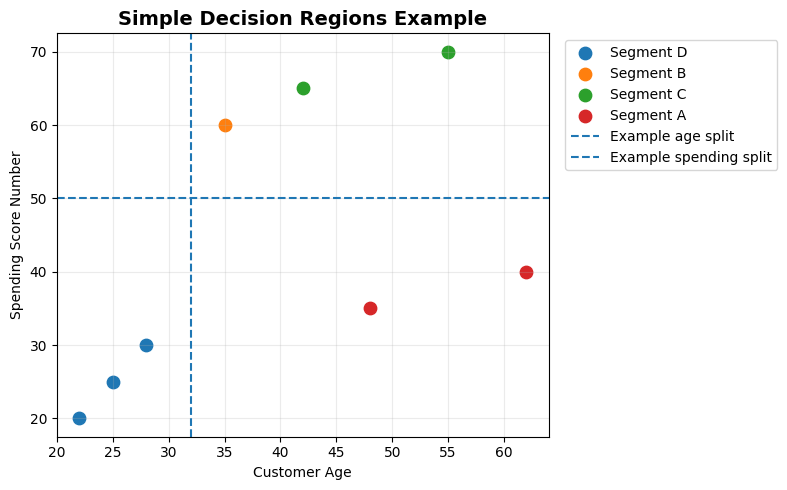

In [12]:
# Code Cell 8A: Simple Decision Region Example

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 1: Create a simple customer example
# ------------------------------------------------------------
# This is a small teaching dataset.
#
# age = customer age
# spending_score_number = simple numeric version of spending score
# segment = customer segment

region_data = pd.DataFrame({
    "age": [22, 25, 28, 35, 42, 48, 55, 62],
    "spending_score_number": [20, 25, 30, 60, 65, 35, 70, 40],
    "segment": ["D", "D", "D", "B", "C", "A", "C", "A"]
})

# ------------------------------------------------------------
# Step 2: Create the chart area
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

# ------------------------------------------------------------
# Step 3: Plot customers by segment
# ------------------------------------------------------------
# Each point = one customer
# x-axis = age
# y-axis = spending score number

for segment_name in region_data["segment"].unique():
    segment_rows = region_data[region_data["segment"] == segment_name]
    
    plt.scatter(
        segment_rows["age"],
        segment_rows["spending_score_number"],
        label=f"Segment {segment_name}",
        s=80
    )

# ------------------------------------------------------------
# Step 4: Add simple decision boundaries
# ------------------------------------------------------------
# These lines are example boundaries.
# They show how a Decision Tree can split the space.
#
# Vertical line = split by age
# Horizontal line = split by spending score

plt.axvline(
    x=32,
    linestyle="--",
    linewidth=1.5,
    label="Example age split"
)

plt.axhline(
    y=50,
    linestyle="--",
    linewidth=1.5,
    label="Example spending split"
)

# ------------------------------------------------------------
# Step 5: Format the chart
# ------------------------------------------------------------

plt.title(
    "Simple Decision Regions Example",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Customer Age")
plt.ylabel("Spending Score Number")

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Decision Regions Interpretation

The chart shows how a Decision Tree can divide customer data into different areas.

Each point represents one customer.

The vertical dashed line is an example age split.

The horizontal dashed line is an example spending score split.

Together, these lines divide the chart into separate decision regions.

A decision region is an area where the model may give the same prediction.

This is why standard Decision Trees often create box-like regions.

They split the data using straight vertical or horizontal cuts.

This works well for simple rule-based patterns, but it can struggle when the real boundary between groups is curved or diagonal.

What the chart shows

Each dot is one customer.

The dashed lines are example Decision Tree splits:

Line	Meaning

Vertical dashed line	Split customers by age

Horizontal dashed line	Split customers by spending score

These two lines divide the chart into different areas. Each area can get a different prediction.

For example:

younger + low spending customers are grouped on the lower-left side,

older + high spending customers are in the upper-right side,

older + low spending customers are in the lower-right side.

## 9. Overfitting in Decision Trees

A Decision Tree can become very large if we let it keep growing.

A large tree asks many questions.

Some questions may be useful.

But too many questions can make the tree memorize the training data.

This problem is called **overfitting**.

## What Overfitting Means

Overfitting happens when a model performs very well on training data but performs worse on new data.

In simple words:

**The model memorized the old examples instead of learning general patterns.**

## Decision Tree Example

A simple tree may learn useful rules such as:

- younger customers with low spending often belong to Segment `D`,
- older customers with high spending may belong to another segment.

A very deep tree may learn tiny rules such as:

- if age is 37,
- profession is artist,
- family size is 3,
- work experience is 8,
- then predict Segment `B`.

This kind of rule may work for a few training customers, but it may not work well for future customers.

## Business Meaning

An overfitted Decision Tree may look strong during training, but it may fail when used on real future customers.

That is why we control tree size using pruning and stopping rules.

In [13]:
# Code Cell 9A: Simple Overfitting Example

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a simple comparison table
# ------------------------------------------------------------
# This table explains the difference between a simple tree
# and an overfitted tree.

overfitting_table = pd.DataFrame({
    "tree_type": [
        "Simple tree",
        "Very deep tree"
    ],
    "training_accuracy": [
        "Medium",
        "Very high"
    ],
    "test_accuracy": [
        "More stable",
        "Often lower"
    ],
    "model_behavior": [
        "Learns general customer patterns",
        "May memorize training customers"
    ],
    "business_risk": [
        "Usually easier to trust",
        "May fail on future customers"
    ]
})

# ------------------------------------------------------------
# Step 2: Display the table
# ------------------------------------------------------------

display(overfitting_table)

,tree_type,training_accuracy,test_accuracy,model_behavior,business_risk
0,Simple tree,Medium,More stable,Learns general customer patterns,Usually easier to trust
1,Very deep tree,Very high,Often lower,May memorize training customers,May fail on future customers


## 10. Pre-pruning and Post-pruning

Pruning is used to control overfitting in Decision Trees.

A Decision Tree can grow very large if we do not control it.

A very large tree may memorize the training data instead of learning useful patterns.

Pruning helps keep the tree simpler and more useful for future data.

## Pre-pruning

Pre-pruning means stopping the tree early while it is growing.

The tree is not allowed to grow beyond certain limits.

Common pre-pruning controls include:

- maximum tree depth,
- minimum samples required to split a node,
- minimum samples required in a leaf node.

In simple words:

**Pre-pruning prevents the tree from becoming too large.**

## Post-pruning

Post-pruning means the tree is allowed to grow first.

After that, weak or unnecessary parts of the tree are removed.

In simple words:

**Post-pruning grows the tree first and then cuts back parts that do not help.**

## Simple Difference

| Method | What Happens |
|---|---|
| Pre-pruning | Stop early while growing |
| Post-pruning | Grow first, then cut back |

Both methods try to reduce overfitting.

In [14]:
# Code Cell 10A: Pruning Methods Overview

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a simple pruning comparison table
# ------------------------------------------------------------
# This table explains the main difference between:
# - pre-pruning
# - post-pruning

pruning_table = pd.DataFrame({
    "pruning_method": [
        "Pre-pruning",
        "Post-pruning"
    ],
    "simple_meaning": [
        "Stop the tree early while it is growing",
        "Grow the tree first, then remove weak parts"
    ],
    "example_controls": [
        "max_depth, min_samples_split, min_samples_leaf",
        "cost-complexity pruning, ccp_alpha"
    ],
    "main_benefit": [
        "Prevents the tree from becoming too large",
        "Can remove unnecessary branches after seeing the full tree"
    ],
    "main_risk": [
        "May stop too early and miss useful patterns",
        "Needs extra checking to decide what to remove"
    ]
})

# ------------------------------------------------------------
# Step 2: Display the table
# ------------------------------------------------------------

display(pruning_table)

,pruning_method,simple_meaning,example_controls,main_benefit,main_risk
0,Pre-pruning,Stop the tree early while it is growing,"max_depth, min_samples_split, min_samples_leaf",Prevents the tree from becoming too large,May stop too early and miss useful patterns
1,Post-pruning,"Grow the tree first, then remove weak parts","cost-complexity pruning, ccp_alpha",Can remove unnecessary branches after seeing t...,Needs extra checking to decide what to remove


### Pruning Methods Interpretation

Pre-pruning and post-pruning both control tree size.

Pre-pruning stops the tree early.

Post-pruning allows the tree to grow first and then removes weak parts.

Pre-pruning is simpler, but it can stop too early.

Post-pruning can be more flexible because the tree first sees more patterns before weak branches are removed.

In practice, common sklearn controls include:

| Control | Meaning |
|---|---|
| `max_depth` | Maximum depth allowed |
| `min_samples_split` | Minimum rows needed to split a node |
| `min_samples_leaf` | Minimum rows required in a final leaf |
| `ccp_alpha` | Cost-complexity pruning strength |

## 11. Cost-Complexity Pruning and ccp_alpha

Cost-complexity pruning is a post-pruning method.

The tree is first allowed to grow.

Then the algorithm checks whether some branches are worth keeping.

A branch should be kept only if it improves the model enough.

If a branch makes the tree more complex but does not improve performance much, it can be removed.

## ccp_alpha

In sklearn, cost-complexity pruning is controlled using `ccp_alpha`.

`ccp_alpha` controls how much we punish tree complexity.

| ccp_alpha Value | Effect |
|---:|---|
| Very small | Larger tree |
| Medium | More balanced tree |
| Large | Smaller tree |

A larger `ccp_alpha` usually creates a smaller tree.

## Simple Meaning

Cost-complexity pruning tries to find a balance between:

1. model performance,
2. model simplicity.

The goal is not to build the biggest tree.

The goal is to build a tree that performs well and is not unnecessarily complex.

In [15]:
# Code Cell 11A: Cost-Complexity Pruning Concept Table

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a simple ccp_alpha explanation table
# ------------------------------------------------------------
# This is a concept table.
# It explains what usually happens when ccp_alpha changes.

ccp_alpha_table = pd.DataFrame({
    "ccp_alpha_level": [
        "Very small",
        "Medium",
        "Large"
    ],
    "tree_size": [
        "Large tree",
        "Balanced tree",
        "Small tree"
    ],
    "possible_behavior": [
        "May overfit because many branches are kept",
        "May balance performance and simplicity",
        "May underfit because too many branches are removed"
    ],
    "business_meaning": [
        "Harder to explain and may memorize training data",
        "Usually easier to explain and still useful",
        "Too simple and may miss important customer patterns"
    ]
})

# ------------------------------------------------------------
# Step 2: Display the table
# ------------------------------------------------------------

display(ccp_alpha_table)

,ccp_alpha_level,tree_size,possible_behavior,business_meaning
0,Very small,Large tree,May overfit because many branches are kept,Harder to explain and may memorize training data
1,Medium,Balanced tree,May balance performance and simplicity,Usually easier to explain and still useful
2,Large,Small tree,May underfit because too many branches are rem...,Too simple and may miss important customer pat...


### Cost-Complexity Pruning Interpretation

`ccp_alpha` controls how much the tree is punished for being complex.

A very small `ccp_alpha` allows the tree to keep many branches.

A larger `ccp_alpha` removes more branches and creates a smaller tree.

The best value is usually somewhere in the middle.

A good pruned tree should be:

- simple enough to explain,
- not too deep,
- not memorizing training data,
- still useful for predicting new customers.

This is why pruning is important in Decision Trees.

### Simple Example of Tree Control Parameters

Decision Tree control parameters help us decide how large or small the tree should become.

#### `max_depth`

`max_depth` controls how many levels of questions the tree can ask.

If `max_depth=1`, the tree asks only one main question.

If `max_depth=3`, the tree can ask more follow-up questions.

A very deep tree may become too complex and memorize the training data.

#### `min_samples_split`

`min_samples_split` controls whether a group is allowed to split again.

For example, if a node has only 6 customers and `min_samples_split=10`, the node cannot split further.

This prevents the tree from creating rules from very small customer groups.

#### `min_samples_leaf`

`min_samples_leaf` controls the minimum number of customers required in a final prediction group.

For example, if `min_samples_leaf=5`, every final leaf must contain at least 5 customers.

This prevents the tree from making predictions based on only one or two customers.

#### `ccp_alpha`

`ccp_alpha` controls post-pruning.

It removes branches that make the tree more complex but do not add enough value.

A small `ccp_alpha` keeps a larger tree.

A larger `ccp_alpha` creates a smaller tree by removing weak branches.

### Simple Summary

| Parameter | Simple Example |
|---|---|
| `max_depth=3` | Tree can ask up to 3 levels of questions |
| `min_samples_split=10` | A group needs at least 10 customers before it can split again |
| `min_samples_leaf=5` | Each final prediction group must have at least 5 customers |
| `ccp_alpha=0.001` | Remove branches that are too complex and not useful enough |

These parameters help the tree learn useful customer patterns without becoming too large or unstable.

## 12. Advanced Pruning Concepts

Pruning means simplifying a Decision Tree.

A Decision Tree can become too large if it keeps asking more and more questions.

A very large tree may memorize small details from the training data.

Pruning helps remove weak, unnecessary, or too-specific parts of the tree.

The goal is to keep useful rules and remove rules that do not help much.

---

## What Is a Subtree?

A subtree is a smaller tree inside the full Decision Tree.

For example, one branch of the tree may contain several follow-up questions.

That branch can be treated as a subtree.

| Tree Part | Simple Meaning                        |
| --------- | ------------------------------------- |
| Full tree | The complete decision system          |
| Branch    | One path inside the tree              |
| Subtree   | A smaller tree inside the larger tree |
| Leaf      | Final prediction point                |

---

## Subtree Replacement

Subtree replacement means replacing a full branch with one final prediction.

Example:

A tree may have a long branch:

| Rule Path                                                              | Prediction |
| ---------------------------------------------------------------------- | ---------- |
| Age > 40 → Profession = Artist → Family_Size = 3 → Work_Experience = 8 | Segment B  |

This rule may be too specific.

It may only work for a few training customers.

Subtree replacement says:

> Replace this long branch with one simple leaf prediction.

So instead of keeping many small rules, the tree may simply predict one segment at that point.

This makes the tree smaller and easier to understand.

---

## Subtree Raising

Subtree raising means moving a useful lower part of the tree higher up.

Sometimes a useful rule is hidden too deep inside the tree.

Example:

| Deep Rule                                              | Prediction |
| ------------------------------------------------------ | ---------- |
| Age > 40 → Profession = Artist → Spending_Score = High | Segment C  |

Maybe the most useful part is actually:

`Spending_Score = High`

Subtree raising tries to move that useful rule higher in the tree.

This can make the tree simpler.

Subtree raising is an advanced pruning idea. We mainly need to understand the concept, not implement it manually.

---

## Error-Based Pruning

Error-based pruning checks whether a branch really improves prediction.

It asks:

> If we remove this branch, do prediction mistakes increase a lot?

If removing the branch does not increase mistakes much, the branch can be removed.

Simple example:

| Situation                                         | Decision          |
| ------------------------------------------------- | ----------------- |
| Removing a branch causes many more mistakes       | Keep the branch   |
| Removing a branch causes almost no extra mistakes | Remove the branch |

The goal is to remove branches that do not improve prediction enough.

---

## Complexity-Based Pruning

Complexity-based pruning checks whether a branch is worth the extra complexity.

A branch may improve accuracy slightly, but it may also make the tree much harder to explain.

Example:

| Tree         | Test Accuracy | Number of Rules |
| ------------ | ------------: | --------------: |
| Simple tree  |           51% |         5 rules |
| Complex tree |           52% |        30 rules |

The complex tree is only slightly better, but it is much harder to explain.

Complexity-based pruning may prefer the simpler tree because the performance improvement is too small.

This is the idea behind cost-complexity pruning and `ccp_alpha`.

---

## MDL Idea

MDL means Minimum Description Length.

The simple idea is:

> Prefer the shorter explanation if it explains the data almost as well.

For Decision Trees, this means:

If a small tree and a large tree perform almost the same, prefer the small tree.

A smaller tree is usually:

* easier to explain,
* easier to trust,
* less likely to memorize noise,
* easier to use in business discussions.

---

## Summary

| Concept                  | Simple Meaning                                           | Main Goal                       |
| ------------------------ | -------------------------------------------------------- | ------------------------------- |
| Subtree replacement      | Replace a full branch with one final prediction          | Make the tree smaller           |
| Subtree raising          | Move a useful lower rule higher                          | Simplify the tree structure     |
| Error-based pruning      | Remove branches that do not reduce errors enough         | Keep only useful branches       |
| Complexity-based pruning | Remove branches that add too much complexity             | Balance accuracy and simplicity |
| MDL idea                 | Prefer the shorter explanation if performance is similar | Keep the model simple           |

The main business lesson is:

**A smaller tree that performs almost as well as a large tree is often better because it is easier to explain and less likely to memorize training noise.**


In [17]:
# Code Cell 12A: Advanced Pruning Concepts Summary

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a simple summary table
# ------------------------------------------------------------
# These concepts are mostly theory.
# This table helps us remember each pruning idea clearly.

advanced_pruning_table = pd.DataFrame({
    "concept": [
        "Subtree replacement",
        "Subtree raising",
        "Error-based pruning",
        "Complexity-based pruning",
        "MDL idea"
    ],
    "simple_meaning": [
        "Replace a full branch with one final prediction",
        "Move a useful lower rule higher in the tree",
        "Remove a branch if it does not reduce mistakes enough",
        "Remove branches that add too much complexity for little benefit",
        "Prefer the shorter explanation if performance is similar"
    ],
    "easy_example": [
        "Replace many tiny customer rules with one Segment D prediction",
        "Move a strong Spending Score rule higher",
        "Remove a branch if test mistakes barely change",
        "Remove a branch that improves accuracy only slightly",
        "Choose a 5-rule tree over a 30-rule tree if both perform similarly"
    ],
    "main_goal": [
        "Make the tree smaller",
        "Simplify the tree structure",
        "Keep only useful branches",
        "Balance accuracy and simplicity",
        "Keep the model simple and explainable"
    ]
})

# ------------------------------------------------------------
# Step 2: Display the table
# ------------------------------------------------------------

display(advanced_pruning_table)

,concept,simple_meaning,easy_example,main_goal
0,Subtree replacement,Replace a full branch with one final prediction,Replace many tiny customer rules with one Segm...,Make the tree smaller
1,Subtree raising,Move a useful lower rule higher in the tree,Move a strong Spending Score rule higher,Simplify the tree structure
2,Error-based pruning,Remove a branch if it does not reduce mistakes...,Remove a branch if test mistakes barely change,Keep only useful branches
3,Complexity-based pruning,Remove branches that add too much complexity f...,Remove a branch that improves accuracy only sl...,Balance accuracy and simplicity
4,MDL idea,Prefer the shorter explanation if performance ...,Choose a 5-rule tree over a 30-rule tree if bo...,Keep the model simple and explainable


### Advanced Pruning Summary Interpretation

The advanced pruning concepts all focus on the same goal:

**make the Decision Tree simpler without losing too much prediction quality.**

Subtree replacement and subtree raising simplify the tree structure.

Error-based pruning checks whether a branch really improves prediction.

Complexity-based pruning checks whether the extra complexity is worth it.

The MDL idea supports choosing a smaller explanation when a smaller tree performs almost as well as a larger tree.

The main lesson is:

A Decision Tree should not keep every possible rule.

It should keep the rules that are useful, stable, and explainable.

# Notebook 2 Final Summary

This notebook covered the missing Decision Tree theory and pruning topics from the uploaded classification materials.

The goal was not to rebuild the previous Decision Tree model.

The goal was to understand how Decision Trees work internally and how pruning controls overfitting.

## What Was Covered

| Area | Status |
|---|---|
| Decision Tree structure | Covered |
| Root node, internal node, branch, and leaf node | Covered |
| Decision path | Covered |
| Gini Index | Covered |
| Comparing splits using Gini | Covered |
| Entropy | Covered |
| Information Gain | Covered |
| Information Gain bias | Covered |
| Gain Ratio concept | Covered |
| Hypothesis space | Covered |
| Greedy search | Covered |
| No backtracking | Covered |
| Inductive bias | Covered |
| Occam’s Razor | Covered |
| Decision regions and decision boundaries | Covered |
| Overfitting in Decision Trees | Covered |
| Pre-pruning | Covered |
| Post-pruning | Covered |
| Common tree control parameters | Covered |
| Cost-complexity pruning and `ccp_alpha` | Covered |
| Subtree replacement | Covered |
| Subtree raising | Covered |
| Error-based pruning | Covered |
| Complexity-based pruning | Covered |
| MDL idea | Covered |

## Main Learning Points

A Decision Tree predicts by asking questions step by step.

Each split tries to make the customer groups cleaner.

Gini Index and Entropy both measure how mixed a group is.

Information Gain measures how much confusion is reduced after a split.

Information Gain can sometimes prefer columns with too many unique values, such as customer IDs. This is why Gain Ratio is useful as a correction idea.

Decision Trees use greedy search. They choose the best-looking split at the current step instead of testing every possible full tree.

A Decision Tree can overfit if it becomes too large.

Pruning helps control tree size and reduce overfitting.

## Key Practical Controls

| Parameter | Purpose |
|---|---|
| `max_depth` | Limits how deep the tree can grow |
| `min_samples_split` | Controls whether a node can split again |
| `min_samples_leaf` | Controls how small final prediction groups can be |
| `ccp_alpha` | Removes branches that add too much complexity |

## Final Business Understanding

A good Decision Tree should be accurate enough, simple enough, and explainable enough.

The best tree is not always the largest tree.

A smaller tree that performs almost as well as a large tree is often better because it is easier to explain and less likely to memorize training noise.